# Phase 2 — Model 3: Variational Autoencoder ($\\beta$-VAE)

**Course:** AML-DL Project | **Authors:** Prerak Arya (230039), Saikiran Bompelliwar (230046)

This notebook implements a Variational Autoencoder (VAE) with $\\beta = 0.5$ for semi-supervised anomaly detection, using reconstruction probability scoring (An & Cho, 2015) with Monte Carlo sampling.

## Model Summary

| Property | Value |
|----------|-------|
| **Type** | Variational Autoencoder ($\\beta$-VAE) |
| **Architecture** | 43 → 128 → 64 → [μ, log σ²] (latent=16) → 64 → 128 → 43 |
| **$\\beta$** | 0.5 (prioritises reconstruction over latent regularity) |
| **Scoring** | Reconstruction probability (50 MC samples) |
| **Loss** | MSE + $\\beta$ · KL divergence |
| **Regularisation** | BatchNorm, Dropout(0.2), Weight Decay(1e-5), Early Stopping |
| **Optimiser** | Adam (lr=1e-3) with ReduceLROnPlateau |
| **References** | Kingma & Welling (2014), An & Cho (2015), Higgins et al. (2017) |

### Architecture Diagram

```
Input (43) ──→ [128] ──→ [64] ──→ ┬──→ μ (16)
                                   │
                                   └──→ log σ² (16)
                                          │
                                          ↓ reparameterise
                                      z = μ + σ·ε  (ε ~ N(0,I))
                                          │
                                          ↓
                                   [64] ──→ [128] ──→ Output (43)
```

---

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys, os
# Handle running from project root or Phase 2 directory
if os.path.isdir('utils'):
    sys.path.insert(0, '.')
elif os.path.isdir('Phase 2/utils'):
    os.chdir('Phase 2')
    sys.path.insert(0, '.')
else:
    raise RuntimeError("Cannot find utils/ directory. Run this notebook from the Phase 2 folder.")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os, time

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from utils.config import SEED, DEVICE, RESULTS_DIR, MODELS_DIR
from utils.models import VAE, vae_loss_fn
from utils.evaluation import compute_vae_score, find_threshold, eval_model, plot_cm, plot_scores

torch.manual_seed(SEED)
np.random.seed(SEED)
print(f"Device: {DEVICE}")

Device: mps


## 1. Load Preprocessed Data

---

In [2]:
data = np.load(os.path.join(RESULTS_DIR, 'processed_data.npz'), allow_pickle=True)
X_train_scaled = data['X_train_scaled']
X_val_normal_scaled = data['X_val_normal_scaled']
X_val_mixed_scaled = data['X_val_mixed_scaled']
X_test_scaled = data['X_test_scaled']
y_val_mixed = data['y_val_mixed']
y_test = data['y_test']
test_attack_cats = data['test_attack_cats']

input_dim = X_train_scaled.shape[1]
print(f"Train: {X_train_scaled.shape}, Input dim: {input_dim}")

Train: (53874, 43), Input dim: 43


## 2. Model Architecture

### Design Choices

- **Latent dimension = 16:** Phase 1 PCA analysis showed ~16 components capture most variance in normal traffic data. This provides enough capacity for the essential structure without redundancy.
- **$\\beta = 0.5$:** Prioritises reconstruction fidelity over latent regularity. For anomaly detection, reconstruction quality directly determines the gap between normal and anomalous scores.
- **No skip connections:** Unlike our AE, the VAE relies on the probabilistic latent space for anomaly scoring. Skip connections would bypass the stochastic bottleneck, undermining the reconstruction probability mechanism.

---

In [3]:
LATENT_DIM = 16
BETA = 0.5

vae_model = VAE(dim=input_dim, latent_dim=LATENT_DIM).to(DEVICE)
n_params = sum(p.numel() for p in vae_model.parameters())

print(f"VAE Architecture (beta={BETA}, latent_dim={LATENT_DIM})")
print("=" * 60)
print(vae_model)
print(f"\nTotal parameters: {n_params:,}")
print(f"Model size: {n_params * 4 / 1024:.1f} KB (float32)")

print(f"\nLayer-by-Layer Parameter Count:")
print("-" * 40)
for name, param in vae_model.named_parameters():
    print(f"  {name:<30} {str(list(param.shape)):>15} = {param.numel():>6,}")

VAE Architecture (beta=0.5, latent_dim=16)
VAE(
  (enc1): Sequential(
    (0): Linear(in_features=43, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2)
    (3): Dropout(p=0.2, inplace=False)
  )
  (enc2): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2)
    (3): Dropout(p=0.2, inplace=False)
  )
  (fc_mu): Linear(in_features=64, out_features=16, bias=True)
  (fc_logvar): Linear(in_features=64, out_features=16, bias=True)
  (dec1): Sequential(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2)
    (3): Dropout(p=0.2, inplace=False)
  )
  (dec2): Sequential(
    (0): Linear(in_features=64, out_feat

## 3. Training

The VAE is trained to minimise $\\mathcal{L}_{\\beta\\text{-VAE}} = \\mathcal{L}_\\text{recon} + \\beta \\cdot D_\\text{KL}$

We train on **all normal data** (no curriculum — VAE's stochastic training already provides regularisation through the reparameterisation noise).

---

In [4]:
optimizer_vae = optim.Adam(vae_model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler_vae = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_vae, mode='min', patience=5, factor=0.5)

train_loader = DataLoader(TensorDataset(torch.FloatTensor(X_train_scaled)),
                          batch_size=128, shuffle=True)

vae_train_losses, vae_val_losses = [], []
vae_recon_losses, vae_kl_losses = [], []
best_vl, pat_ctr = float('inf'), 0
MAX_EPOCHS = 100
VAE_PATIENCE = 15

print("=" * 60)
print(f"TRAINING: VAE (beta={BETA}, latent={LATENT_DIM})")
print("=" * 60)
t_start = time.time()

for epoch in range(MAX_EPOCHS):
    vae_model.train()
    tl, tr, tk, ns = 0, 0, 0, 0
    for batch in train_loader:
        x = batch[0].to(DEVICE)
        recon, mu, logvar = vae_model(x)
        loss, rl, kl = vae_loss_fn(recon, x, mu, logvar, BETA)
        optimizer_vae.zero_grad()
        loss.backward()
        optimizer_vae.step()
        tl += loss.item() * len(x)
        tr += rl.item() * len(x)
        tk += kl.item() * len(x)
        ns += len(x)

    vae_train_losses.append(tl / ns)
    vae_recon_losses.append(tr / ns)
    vae_kl_losses.append(tk / ns)

    vae_model.eval()
    with torch.no_grad():
        vx = torch.FloatTensor(X_val_normal_scaled).to(DEVICE)
        vr, vm, vlv = vae_model(vx)
        vl, _, _ = vae_loss_fn(vr, vx, vm, vlv, BETA)
        vl = vl.item()
    vae_val_losses.append(vl)
    scheduler_vae.step(vl)

    if vl < best_vl:
        best_vl = vl
        pat_ctr = 0
        torch.save(vae_model.state_dict(), os.path.join(MODELS_DIR, 'best_vae.pth'))
    else:
        pat_ctr += 1

    if pat_ctr >= VAE_PATIENCE:
        print(f"Early stopping at epoch {epoch + 1}")
        break

    if (epoch + 1) % 10 == 0:
        lr = optimizer_vae.param_groups[0]['lr']
        print(f"  Epoch {epoch+1:>3d}: Total={vae_train_losses[-1]:.6f} "
              f"(Recon={vae_recon_losses[-1]:.6f}, KL={vae_kl_losses[-1]:.6f}) "
              f"Val={vl:.6f} LR={lr:.2e}")

total_time = time.time() - t_start
vae_model.load_state_dict(torch.load(os.path.join(MODELS_DIR, 'best_vae.pth'), map_location=DEVICE))
print(f"\nTraining complete in {total_time:.1f}s")
print(f"Best val loss: {best_vl:.6f} at epoch {epoch + 1 - pat_ctr}")

TRAINING: VAE (beta=0.5, latent=16)


  Epoch  10: Total=0.582432 (Recon=0.475188, KL=0.214488) Val=1.999209 LR=1.00e-03


  Epoch  20: Total=0.542546 (Recon=0.433235, KL=0.218622) Val=1.106911 LR=2.50e-04


  Epoch  30: Total=0.533433 (Recon=0.423829, KL=0.219210) Val=1.061155 LR=2.50e-04


  Epoch  40: Total=0.525931 (Recon=0.415901, KL=0.220060) Val=0.992789 LR=1.25e-04


  Epoch  50: Total=0.521062 (Recon=0.411093, KL=0.219937) Val=1.027810 LR=3.13e-05


Early stopping at epoch 59

Training complete in 123.1s
Best val loss: 0.930729 at epoch 44


## 4. Training Curves

We plot both the total loss and its decomposition into reconstruction and KL components. The reconstruction loss should dominate (since $\\beta = 0.5$ down-weights KL).

---

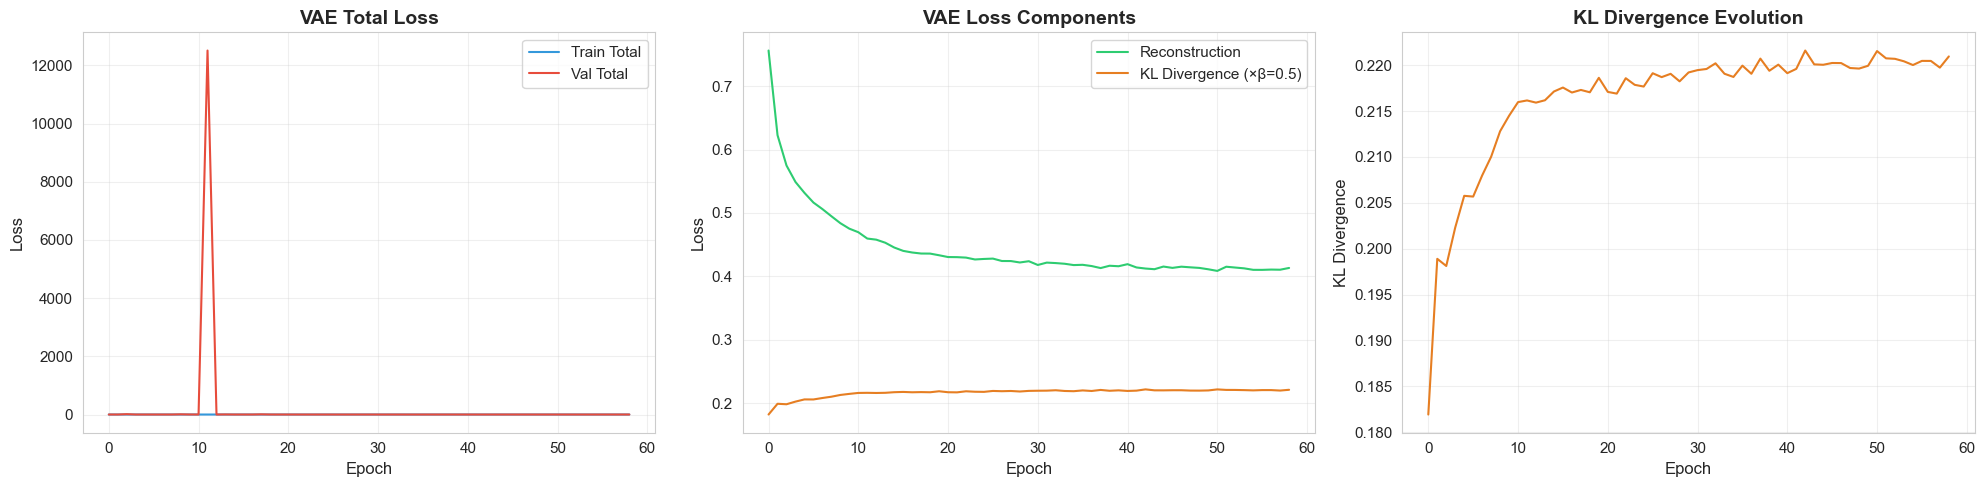

Final training loss breakdown:
  Reconstruction: 0.413197
  KL Divergence:  0.220955
  Weighted KL:    0.110477
  Total:          0.523675


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Total loss
axes[0].plot(vae_train_losses, label='Train Total', color='#3498db', linewidth=1.5)
axes[0].plot(vae_val_losses, label='Val Total', color='#e74c3c', linewidth=1.5)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('VAE Total Loss', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Components
axes[1].plot(vae_recon_losses, label='Reconstruction', color='#2ecc71', linewidth=1.5)
axes[1].plot(vae_kl_losses, label=f'KL Divergence (×β={BETA})', color='#e67e22', linewidth=1.5)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('VAE Loss Components', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# KL divergence evolution (tracks latent space regularity)
axes[2].plot(vae_kl_losses, color='#e67e22', linewidth=1.5)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('KL Divergence')
axes[2].set_title('KL Divergence Evolution', fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'vae_loss_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Final training loss breakdown:")
print(f"  Reconstruction: {vae_recon_losses[-1]:.6f}")
print(f"  KL Divergence:  {vae_kl_losses[-1]:.6f}")
print(f"  Weighted KL:    {BETA * vae_kl_losses[-1]:.6f}")
print(f"  Total:          {vae_train_losses[-1]:.6f}")

## 5. Reconstruction Probability Scoring

Instead of a single-point reconstruction error, we sample 50 latent vectors from $q(z|x)$ and average the reconstruction errors. This Monte Carlo estimate provides a more robust anomaly score.

$$\\text{Score}(x) = \\frac{1}{L}\\sum_{l=1}^L \\|x - D(z^{(l)})\\|^2, \\quad z^{(l)} \\sim \\mathcal{N}(\\mu(x), \\sigma^2(x) I)$$

---

In [6]:
print("Computing VAE reconstruction probability (50 MC samples)...")
print("This may take a moment...")

t0 = time.time()
vae_val_scores = compute_vae_score(vae_model, X_val_mixed_scaled, DEVICE, n_samples=50)
vae_threshold, vae_val_f1 = find_threshold(vae_val_scores, y_val_mixed)
print(f"Threshold selection time: {time.time()-t0:.1f}s")
print(f"Optimal threshold (val): {vae_threshold:.6f}")
print(f"Validation F1: {vae_val_f1:.4f}")

t0 = time.time()
vae_test_scores = compute_vae_score(vae_model, X_test_scaled, DEVICE, n_samples=50)
print(f"Test scoring time: {time.time()-t0:.1f}s")

vae_test_preds = (vae_test_scores > vae_threshold).astype(int)
vae_metrics = eval_model(y_test, vae_test_preds, vae_test_scores, f'VAE (beta={BETA})')

Computing VAE reconstruction probability (50 MC samples)...
This may take a moment...


Threshold selection time: 1.6s
Optimal threshold (val): 0.024659
Validation F1: 0.6712


Test scoring time: 0.9s

VAE (beta=0.5) — TEST RESULTS
              precision    recall  f1-score   support

      Normal       1.00      0.03      0.06      9711
     Anomaly       0.58      1.00      0.73     12833

    accuracy                           0.58     22544
   macro avg       0.79      0.52      0.40     22544
weighted avg       0.76      0.58      0.44     22544

ROC-AUC: 0.9407


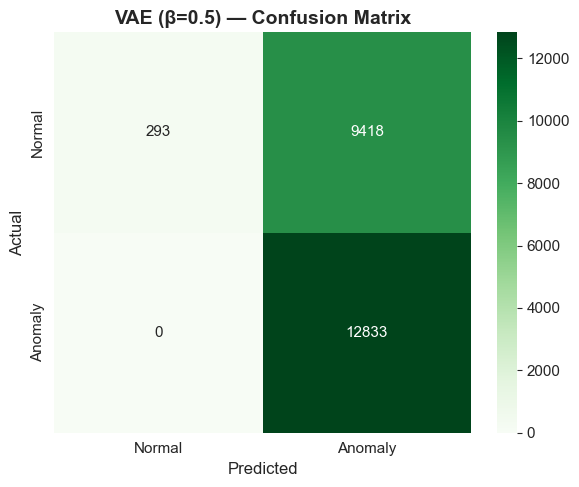

In [7]:
plot_cm(y_test, vae_test_preds, f'VAE (β={BETA}) — Confusion Matrix',
        os.path.join(RESULTS_DIR, 'vae_cm.png'), 'Greens')

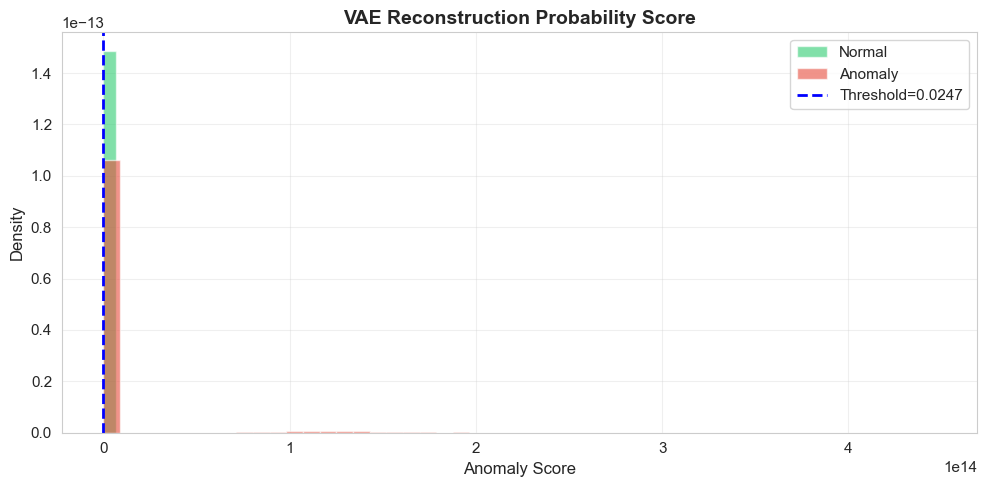

In [8]:
plot_scores(vae_test_scores, y_test, vae_threshold,
            'VAE Reconstruction Probability Score',
            os.path.join(RESULTS_DIR, 'vae_scores.png'))

## 6. Per-Attack-Family Analysis

---

In [9]:
print("VAE: Per-Attack-Family Detection Rate")
print("=" * 55)
print(f"{'Family':<10} {'Total':>7} {'Detected':>10} {'Rate':>8}")
print("-" * 55)
for fam in ['DoS', 'Probe', 'R2L', 'U2R']:
    mask = test_attack_cats == fam
    total = mask.sum()
    if total == 0: continue
    detected = vae_test_preds[mask].sum()
    print(f"{fam:<10} {total:>7,d} {detected:>10,d} {detected/total:>7.1%}")

nm = test_attack_cats == 'Normal'
fp = vae_test_preds[nm].sum()
print("-" * 55)
print(f"{'Normal(FP)':<10} {nm.sum():>7,d} {fp:>10,d} {fp/nm.sum():>7.1%}")

VAE: Per-Attack-Family Detection Rate
Family       Total   Detected     Rate
-------------------------------------------------------
DoS          7,458      7,458  100.0%
Probe        2,421      2,421  100.0%
R2L          2,887      2,887  100.0%
U2R             67         67  100.0%
-------------------------------------------------------
Normal(FP)   9,711      9,418   97.0%


## 7. Latent Space Visualisation

We visualise the VAE's learned latent space in 2D. A well-structured latent space should show smooth organisation with normal and anomalous data occupying different regions.

---

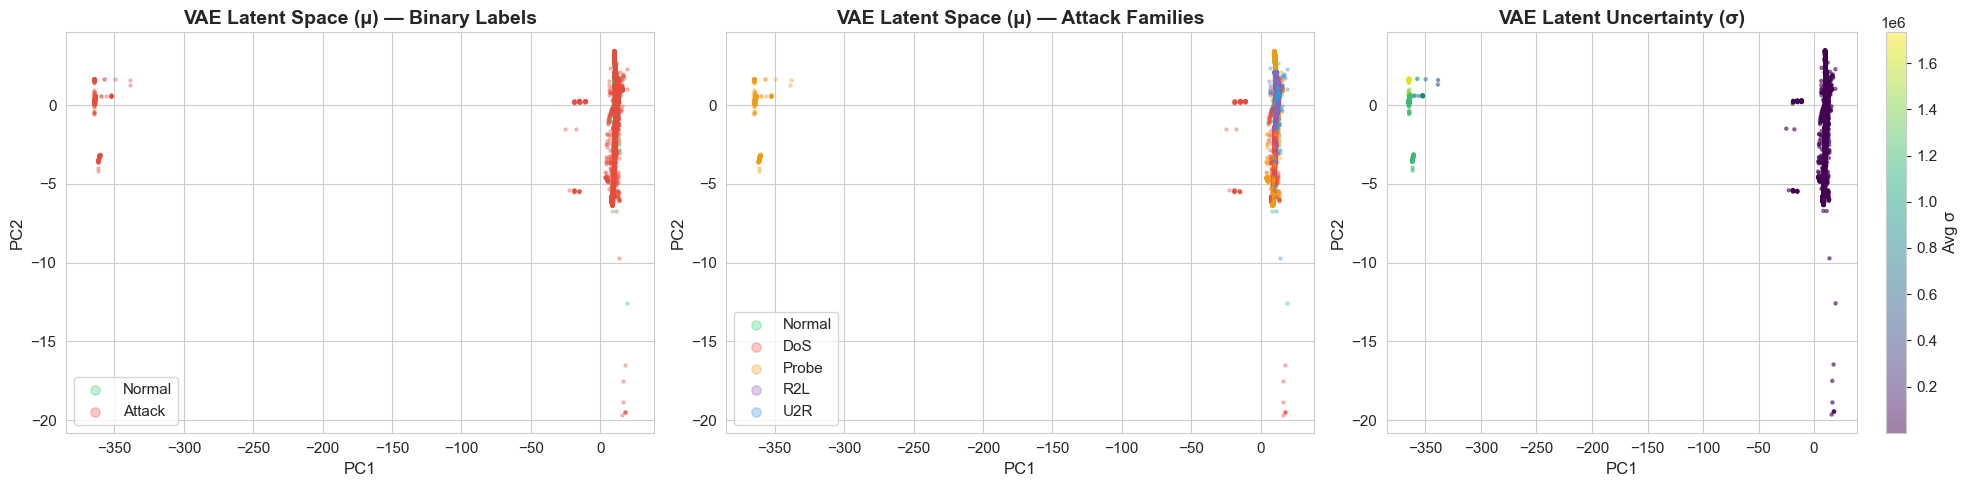


Latent space statistics:
  Normal samples — avg |μ|: 0.1250, avg σ: 178.2079
  Attack samples — avg |μ|: 2.9878, avg σ: 61581.2656


In [10]:
from sklearn.decomposition import PCA

vae_model.eval()
with torch.no_grad():
    vae_mu, vae_logvar = vae_model.encode(torch.FloatTensor(X_test_scaled).to(DEVICE))
    vae_emb = vae_mu.cpu().numpy()
    vae_sigma = torch.exp(0.5 * vae_logvar).cpu().numpy()

pca_latent = PCA(n_components=2, random_state=SEED)
latent_2d = pca_latent.fit_transform(vae_emb)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# By binary label
for label, color, name in [(0, '#2ecc71', 'Normal'), (1, '#e74c3c', 'Attack')]:
    mask = y_test == label
    axes[0].scatter(latent_2d[mask, 0], latent_2d[mask, 1], c=color,
                    s=5, alpha=0.3, label=name)
axes[0].set_title('VAE Latent Space (μ) — Binary Labels', fontweight='bold')
axes[0].legend(markerscale=3)

# By attack family
family_colors = {'Normal': '#2ecc71', 'DoS': '#e74c3c', 'Probe': '#f39c12',
                 'R2L': '#9b59b6', 'U2R': '#3498db'}
for fam, color in family_colors.items():
    mask = test_attack_cats == fam
    if mask.sum() > 0:
        axes[1].scatter(latent_2d[mask, 0], latent_2d[mask, 1], c=color,
                        s=5, alpha=0.3, label=fam)
axes[1].set_title('VAE Latent Space (μ) — Attack Families', fontweight='bold')
axes[1].legend(markerscale=3)

# Latent uncertainty (average sigma per sample)
avg_sigma = vae_sigma.mean(axis=1)
scatter = axes[2].scatter(latent_2d[:, 0], latent_2d[:, 1],
                          c=avg_sigma, cmap='viridis', s=5, alpha=0.5)
plt.colorbar(scatter, ax=axes[2], label='Avg σ')
axes[2].set_title('VAE Latent Uncertainty (σ)', fontweight='bold')

for ax in axes:
    ax.set_xlabel(f'PC1')
    ax.set_ylabel(f'PC2')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'vae_latent_space.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\nLatent space statistics:")
print(f"  Normal samples — avg |μ|: {np.abs(vae_emb[y_test==0]).mean():.4f}, "
      f"avg σ: {vae_sigma[y_test==0].mean():.4f}")
print(f"  Attack samples — avg |μ|: {np.abs(vae_emb[y_test==1]).mean():.4f}, "
      f"avg σ: {vae_sigma[y_test==1].mean():.4f}")

## 8. Save Results

---

In [11]:
np.save(os.path.join(MODELS_DIR, 'vae_test_embeddings.npy'), vae_emb)
np.save(os.path.join(MODELS_DIR, 'vae_test_scores.npy'), vae_test_scores)
np.save(os.path.join(MODELS_DIR, 'vae_test_preds.npy'), vae_test_preds)

metrics_df = pd.DataFrame([vae_metrics])
metrics_df.to_csv(os.path.join(RESULTS_DIR, 'vae_metrics.csv'), index=False)

print("Saved:")
print(f"  Model weights: {os.path.join(MODELS_DIR, 'best_vae.pth')}")
print(f"  Latent embeddings (μ): {os.path.join(MODELS_DIR, 'vae_test_embeddings.npy')} shape={vae_emb.shape}")
print(f"  Scores: {os.path.join(MODELS_DIR, 'vae_test_scores.npy')}")
print(f"  Metrics: {os.path.join(RESULTS_DIR, 'vae_metrics.csv')}")
print(f"\nVAE latent embeddings saved for Phase 3 hybrid model.")

Saved:
  Model weights: /Users/bompelliwarsaikiran/Desktop/AML-DL-Project/Phase 2/utils/../models/best_vae.pth
  Latent embeddings (μ): /Users/bompelliwarsaikiran/Desktop/AML-DL-Project/Phase 2/utils/../models/vae_test_embeddings.npy shape=(22544, 16)
  Scores: /Users/bompelliwarsaikiran/Desktop/AML-DL-Project/Phase 2/utils/../models/vae_test_scores.npy
  Metrics: /Users/bompelliwarsaikiran/Desktop/AML-DL-Project/Phase 2/utils/../results/vae_metrics.csv

VAE latent embeddings saved for Phase 3 hybrid model.
